# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary.

<font color="MidnightBlue">The goal of this analisys is to find which features of the dataset have the greatest impact on the price of a used car.</font>

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

<font color="MidnightBlue">I want to see the first 5 rows to have an idea what kind of columns the dataset has and run .info() to see the datatypes. As we can see, there are typical car features like paint color, fuel and cylinderd etc. And the df contains primerly string data type</font>

In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("./data/vehicles.csv")
df.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


In [97]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  str    
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  str    
 5   model         421603 non-null  str    
 6   condition     252776 non-null  str    
 7   cylinders     249202 non-null  str    
 8   fuel          423867 non-null  str    
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  str    
 11  transmission  424324 non-null  str    
 12  VIN           265838 non-null  str    
 13  drive         296313 non-null  str    
 14  size          120519 non-null  str    
 15  type          334022 non-null  str    
 16  paint_color   296677 non-null  str    
 17  state         426880 non-null  str    
dtypes: float64(2), 

<font color="MidnightBlue"> Now I want to explore the missing data. </font>

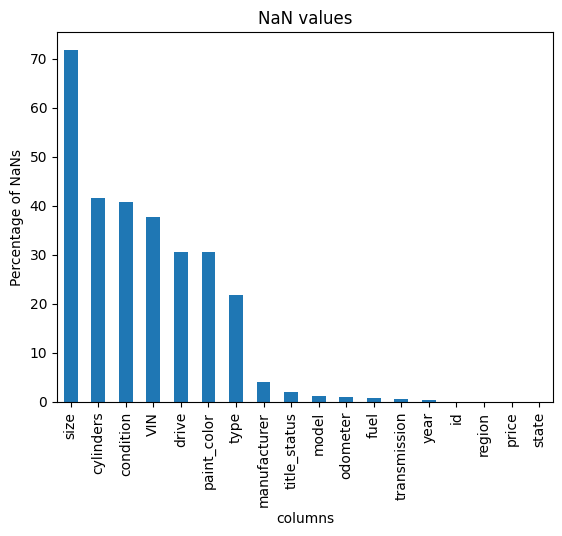

In [98]:
nan_counts = df.isna().sum().sort_values(ascending=False)
nan_counts = (nan_counts / df.shape[0]) * 100
nan_counts.plot(kind='bar')
plt.title("NaN values")
plt.ylabel("Percentage of NaNs")
plt.xlabel("columns")
plt.show()

<font color="MidnightBlue"> 70% of the "size" column are missing and almost a half of the information about cylinders and condition are missing, and more then a third information for VIN.
I want to explore the missing data and see what I can do about it. First, I want to check how size column looks like. Briefly looking at the notnull sizes, I saw that this data is categorical, so maybe I can find the momdel or make information and fillup the missing size information for the similar models/makes.
</font>

In [99]:
df[~df["size"].isna()][["manufacturer", "model", "size"]]

,manufacturer,model,size
31,ford,f-150 xlt,full-size
46,jeep,compass,full-size
55,ford,f250 super duty,full-size
59,honda,odyssey,full-size
65,ford,f450,full-size
...,...,...,...
426809,jeep,gand wagoneer,full-size
426831,nissan,300zx coupe with t-tops,sub-compact
426833,jaguar,xk8 convertible,compact
426836,ram,2500,full-size


<font color="MidnightBlue"> However, this result shows that some model names can have different sizes. I am so bad with cars, I know nothing about them. so maybe the type will help.  </font>

In [100]:
pd.crosstab(df["model"], df["size"])
df.groupby("model")["size"].nunique().sort_values(ascending=False)

model
explorer                       4
fit                            4
fusion se                      4
wrx                            4
challenger                     4
                              ..
e350 14 passenger van          0
e350 12' box van               0
e350 12' box truck             0
e320 4matic                    0
🔥GMC Sierra 1500 SLE🔥 4X4 🔥    0
Name: size, Length: 29649, dtype: int64

In [101]:
df[(df["model"].isin(["explorer", "fit", "fusion se", "wrx", "challenger"])) & (~df["size"].isna())][["model", "manufacturer", "size", "type", "year"]]

,model,manufacturer,size,type,year
2090,fusion se,ford,full-size,sedan,2013.0
2196,explorer,ford,mid-size,SUV,2013.0
2222,explorer,ford,mid-size,SUV,2016.0
3835,explorer,ford,full-size,SUV,2018.0
3934,explorer,ford,full-size,SUV,2016.0
...,...,...,...,...,...
424172,fusion se,ford,mid-size,sedan,2010.0
424918,explorer,ford,full-size,pickup,2015.0
425133,fusion se,ford,mid-size,sedan,2012.0
425444,explorer,ford,full-size,SUV,2013.0


<font color = "MidnightBlue">Nope, type hasn't help. They can be SUVs with different sizes. </font>

In [102]:
df.groupby(["manufacturer", "model", "year", "type"])["size"].nunique().sort_values(ascending=False)


manufacturer  model                       year    type       
ford          mustang                     2012.0  coupe          4
              fiesta                      2011.0  sedan          4
              mustang                     1996.0  coupe          4
                                          2004.0  convertible    4
                                          2006.0  coupe          4
                                                                ..
gmc           sierra duramax 2500 hd 4x4  2017.0  truck          0
                                          2020.0  truck          0
              sierra duramax 2500 hd all  2015.0  truck          0
              sierra duramax 2500 hd at4  2020.0  truck          0
volvo         xc90t6 awd 24733 miles      2018.0  SUV            0
Name: size, Length: 59215, dtype: int64

In [108]:
df[(df["model"] == "mustang") & (df["year"] == 2011.0) & (df["type"] == "coupe") & (df["size"].notna())][["size", "title_status", "manufacturer", "cylinders"]]

,size,title_status,manufacturer,cylinders
107166,mid-size,clean,ford,6 cylinders
242844,compact,clean,ford,8 cylinders
347814,full-size,clean,ford,6 cylinders
366024,sub-compact,clean,ford,8 cylinders


<font color = "Midnightblue"> So my hypothesis did not work out, it is possible to have different sizes for the cars even if they have the same model name, year and type. But I cannot get rid of the 70% percent of data. Maybe I will replace the size with the most common for a particluar model and year. I am moving to cylinders exploration </font>

In [122]:
df.groupby(["manufacturer", "model", "year", "fuel", "type"])["cylinders"].nunique().sort_values(ascending=False)

manufacturer   model                   year    fuel   type 
honda          accord                  2004.0  gas    coupe    4
bmw            5 series                2014.0  gas    sedan    4
honda          civic                   2010.0  gas    sedan    4
jeep           cherokee                2016.0  gas    SUV      4
ford           escape                  2020.0  gas    SUV      4
                                                              ..
chrysler       pt crusier              2007.0  gas    wagon    0
mercedes-benz  e-class e 300           2018.0  other  sedan    0
                                               gas    sedan    0
                                       2017.0  gas    sedan    0
volvo          xc90t6 awd 24733 miles  2018.0  gas    SUV      0
Name: cylinders, Length: 63075, dtype: int64

In [134]:
df[(df["model"] == "accord") & (df["year"] == 2004.0) & (df["type"] == "coupe") & (df["cylinders"].notna()) & (df["fuel"] == "gas")][["cylinders", "size"]]

,cylinders,size
104038,6 cylinders,NaN
123382,4 cylinders,compact
178089,6 cylinders,mid-size
179636,4 cylinders,compact
196796,3 cylinders,compact
230812,4 cylinders,NaN
234549,4 cylinders,NaN
257566,6 cylinders,mid-size
275446,6 cylinders,NaN
347486,4 cylinders,NaN


<font color="MidnightBlue">The field above is the demonstration that the same model, year and type can have different number of cylinders. Maybe I can research how the cylinders are related to the size and pick the most common for each missing value. </font>

In [133]:
pd.crosstab(df["size"], df["cylinders"])

cylinders,10 cylinders,12 cylinders,3 cylinders,4 cylinders,5 cylinders,6 cylinders,8 cylinders,other
size,,,,,,,,
compact,199,6,151,11080,207,2616,1214,228
full-size,679,57,60,8018,296,20089,27230,221
mid-size,39,21,41,16035,361,13553,3467,77
sub-compact,12,4,43,1436,28,438,225,32


<font color = "MidnightBluew">Moving to condition exploration.</font>

In [141]:
df["condition"].value_counts().sort_values(ascending=False)

condition
good         121456
excellent    101467
like new      21178
fair           6769
new            1305
salvage         601
Name: count, dtype: int64

<font color="MidnightBlue">Here we see that most of the cars are in "good" and "excellent" condition, and further the worse the condition is, the lower is the count for such cars. We have a big chunk of data with missing condition values, so I am going to explore its relationship with odometer, title_status (I had to research the meaning of this feature) In the data preparation phase I will dive deeper into the relationship berween these three features, since some data type transformation has to be done.</font>

In [154]:
df[df["condition"].notna()][["year", "odometer", "condition"]]


,year,odometer,condition
27,2014.0,57923.0,good
28,2010.0,71229.0,good
29,2020.0,19160.0,good
30,2017.0,41124.0,good
31,2013.0,128000.0,excellent
...,...,...,...
426875,2019.0,32226.0,good
426876,2020.0,12029.0,good
426877,2020.0,4174.0,good
426878,2018.0,30112.0,good


### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.